In [66]:
# 1.Import Library
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ftfy import fix_text

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [84]:
# 2.Load Dataset
df = pd.read_excel("dating_app_behavior_dataset.csv.xlsx")
df.head()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor's,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master's,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor's,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [ ]:
# 3. Exploratory Data Analysis (EDA)
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
Index: 24979 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                24979 non-null  str    
 1   sexual_orientation    24979 non-null  str    
 2   location_type         24979 non-null  str    
 3   income_bracket        24979 non-null  str    
 4   education_level       24979 non-null  str    
 5   interest_tags         24979 non-null  str    
 6   app_usage_time_min    24979 non-null  int64  
 7   app_usage_time_label  24979 non-null  str    
 8   swipe_right_ratio     24979 non-null  float64
 9   swipe_right_label     24979 non-null  str    
 10  likes_received        24979 non-null  int64  
 11  mutual_matches        24979 non-null  int64  
 12  profile_pics_count    24979 non-null  int64  
 13  bio_length            24979 non-null  int64  
 14  message_sent_count    24979 non-null  int64  
 15  emoji_usage_rate      24979 non-nul

In [123]:
# 4. Data Preprocessing
target_map = {
    "Mutual Match": "Mutual Match",
    "Ghosted": "Ghosted",
    "Catfished": "Catfished",
    "Chat Ignored": "No Response",
    "No Action": "No Response"
}

df = df[df["match_outcome"].isin(target_map.keys())].copy()
df["relationship_outcome"] = df["match_outcome"].map(target_map)
print(df["relationship_outcome"].value_counts())

relationship_outcome
No Response     10005
Catfished        5025
Mutual Match     4990
Ghosted          4959
Name: count, dtype: int64


In [124]:
#Fix the text
df = df.replace('Bachelorâ€™s', "Bachelor's", regex=True)

In [140]:
# 5. Feature Selection

df['num_interests'] = df['interest_tags'].apply(lambda x: len(x.split(', ')))

top_features = [
    'message_sent_count', 'bio_length', 'likes_received',
    'app_usage_time_min', 'emoji_usage_rate', 'last_active_hour',
    'mutual_matches', 'profile_pics_count', 'num_interests'
]
X = df[top_features]
y = df['match_outcome']

In [135]:
#Encoding 
pd.get_dummies(df['gender'])
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [143]:

# Menampilkan semua nama kolom dalam bentuk List
print(df.columns.tolist())

# Menampilkan jumlah kolom
print(f"Total kolom: {len(df.columns)}")

['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'interest_tags', 'app_usage_time_min', 'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'match_outcome', 'num_interests', 'relationship_outcome']
Total kolom: 21


In [142]:
#Split Data(Training 80%, Test 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [144]:
# 6. Model Training
#RandomForest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [108]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy with Top 9 Features: {accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy with Top 9 Features: 0.1867

Classification Report:

              precision    recall  f1-score   support

   Catfished       0.19      0.20      0.20       991
Chat Ignored       0.18      0.18      0.18      1033
     Ghosted       0.18      0.20      0.19       955
Mutual Match       0.19      0.19      0.19       996
   No Action       0.19      0.17      0.18      1021

    accuracy                           0.19      4996
   macro avg       0.19      0.19      0.19      4996
weighted avg       0.19      0.19      0.19      4996



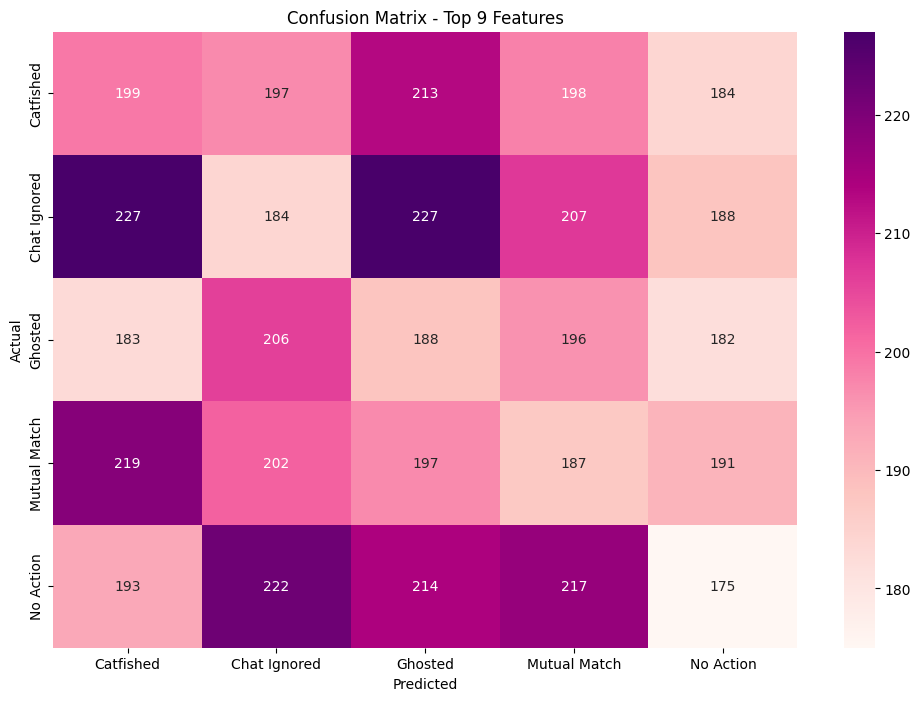

In [87]:
# 8. VISUALISASI CONFUSION MATRIX (Agar laporanmu keren)
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Top 9 Features")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_21772\1079765674.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="magma")


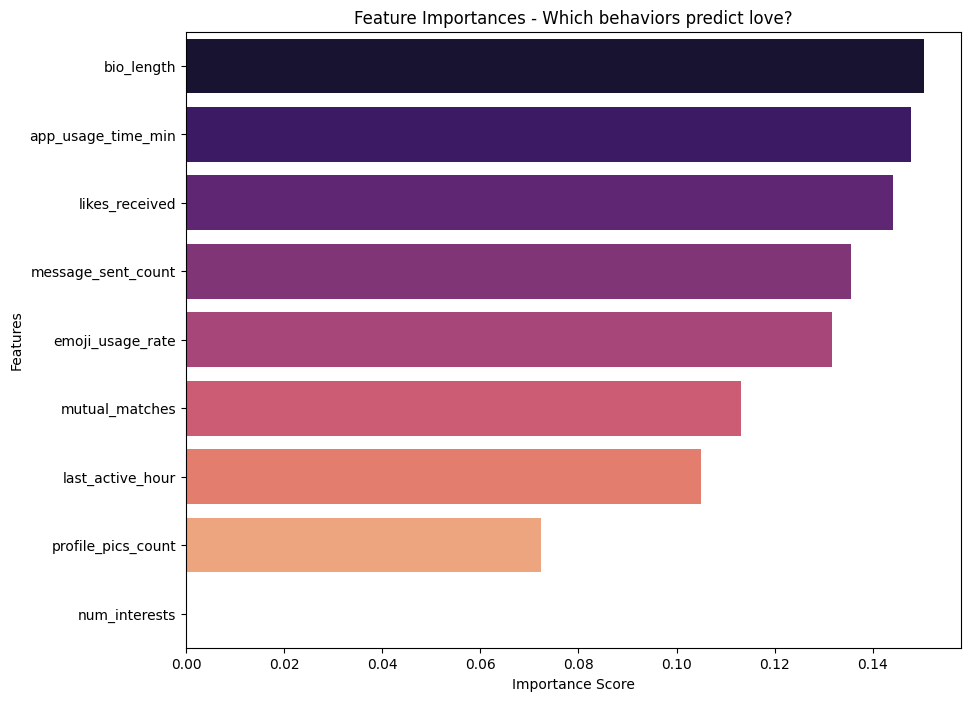

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Pastikan model sudah dilatih (fit)
# rf_model adalah nama variabel model Random Forest kamu
importances = rf_model.feature_importances_

# 2. Ambil nama kolom dari data X kamu
feature_names = X.columns

# 3. Urutkan fitur dari yang paling penting ke yang paling rendah
indices = np.argsort(importances)[::-1]

# 4. Visualisasikan dalam bentuk grafik batang (Bar Chart)
plt.figure(figsize=(10, 8))
plt.title("Feature Importances - Which behaviors predict love?")
sns.barplot(x=importances[indices], y=feature_names[indices], palette="magma")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()